In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from src.measure_ir import *

In [2]:
data = np.load(r".\data\no_cancel_data.npz")

source    = data["source"]
no_panel  = data["no_panel"]
no_cancel = data["no_cancel"]
error_nc  = data["error_nc"]
ref_nc    = data["ref_nc"]

In [3]:
# Load your measured panel -> error IR
irs = np.load(r".\data\current_irs.npz")
error_ir, ref_ir = align_irs_by_distance(irs["error_ir"], irs["ref_ir"], distance_cm=4.5, ir_len=256, fs=96_000)

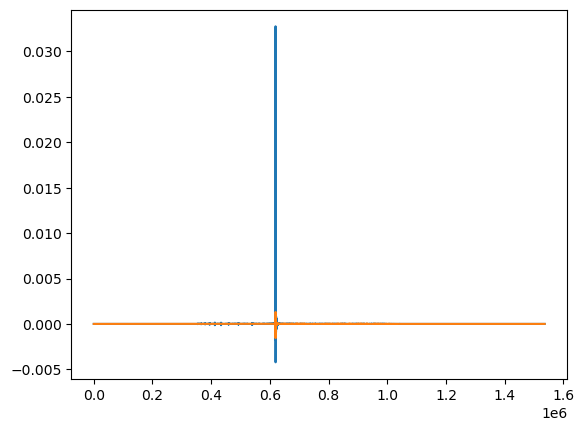

In [61]:
plt.plot(irs["error_ir"], label="error_ir")
plt.plot(irs["ref_ir"], label="ref_ir")

In [4]:
M = 1024

start = 0
length = int(10 * 96_000)
error = error_nc[start:start + length].astype(np.float64)
ref = ref_nc[start:start + length].astype(np.float64)

In [5]:
xf0 = fftconvolve(ref, error_ir, mode="full")[:len(ref)]

In [6]:
def lsquare(X_train, d_train, X_test, d_test, lam):
    if lam == 0:
        w, *_ = np.linalg.lstsq(
            X_train,
            -d_train,
            rcond=None,
        )
    else:
        X_aug = np.vstack([
            X_train,
            np.sqrt(lam) * np.eye(M),
        ])

        d_aug = np.concatenate([
            -d_train,
            np.zeros(M),
        ])

        w, *_ = np.linalg.lstsq(
            X_aug,
            d_aug,
            rcond=None,
        )

    train_residual = d_train + X_train @ w
    test_residual = d_test + X_test @ w

    train_db = 10 * np.log10(
        np.mean(train_residual**2) /
        np.mean(d_train**2)
    )

    test_db = 10 * np.log10(
        np.mean(test_residual**2) /
        np.mean(d_test**2)
    )

    print("Train:", train_db)
    print("Test:", test_db)
    print("Norm:", np.linalg.norm(w))

    return w, train_db, test_db

In [7]:
delays = [0, 20, 40, 60, 80, 86, 100, 120, 140, 160]

for delay in delays:
    xf = np.zeros_like(xf0)

    if delay == 0:
        xf[:] = xf0
    else:
        xf[delay:] = xf0[:-delay]

    N = len(xf)

    X_delay = np.zeros(
        (N - M + 1, M),
        dtype=np.float64,
    )

    for k in range(M):
        X_delay[:, k] = xf[M - 1 - k : N - k]

    d_delay = error[M - 1:].astype(np.float64)

    split = len(d_delay) // 2

    X_train = X_delay[:split]
    d_train = d_delay[:split]

    X_test = X_delay[split:]
    d_test = d_delay[split:]

    w, train_db, test_db = lsquare(
        X_train,
        d_train,
        X_test,
        d_test,
        lam=1e-2,
    )

    print(
        f"delay={delay:3d}  "
        f"train={train_db:.2f} dB  "
        f"test={test_db:.2f} dB  "
        f"norm={np.linalg.norm(w):.2f}"
    )

Train: -18.074806166697716
Test: -17.441508045543625
Norm: 1.710377845779441
delay=  0  train=-18.07 dB  test=-17.44 dB  norm=1.71
Train: -18.177981451738344
Test: -17.582136231628557
Norm: 1.718408703355433
delay= 20  train=-18.18 dB  test=-17.58 dB  norm=1.72
Train: -18.383293625827598
Test: -17.834949283500446
Norm: 1.7256701386365072
delay= 40  train=-18.38 dB  test=-17.83 dB  norm=1.73
Train: -18.51899918303789
Test: -18.004583829237678
Norm: 1.718728086134129
delay= 60  train=-18.52 dB  test=-18.00 dB  norm=1.72
Train: -18.627522159860067
Test: -18.117825144962957
Norm: 1.716705878693089
delay= 80  train=-18.63 dB  test=-18.12 dB  norm=1.72
Train: -18.63284382752576
Test: -18.122791745143132
Norm: 1.7154756806578284
delay= 86  train=-18.63 dB  test=-18.12 dB  norm=1.72
Train: -18.633831533001178
Test: -18.121920327891264
Norm: 1.7163588193026185
delay=100  train=-18.63 dB  test=-18.12 dB  norm=1.72
Train: -18.633288016320503
Test: -18.119590698366657
Norm: 1.7189804097272265
dela

In [28]:
data = np.load(r".\data\ir_comps.npz")

error_on = data["error_on"]
error_off = data["error_off"]
ref_on = data["ref_on"]
ref_off = data["ref_off"]
cancel_gain = data["cancel_gain"]

w_opt = np.load(r".\data\w_opt_lam_1e-2.npy")
w_opt.shape


(1024,)

In [45]:
length = 5 * 96_000

In [46]:
actual_panel_effect = error_on - error_off

In [47]:
control = -cancel_gain * fftconvolve(
    ref_on,
    w_opt,
    mode="full"
)[:len(ref_on)]

predicted_panel_effect = fftconvolve(
    control,
    error_ir,
    mode="full"
)[:len(control)]

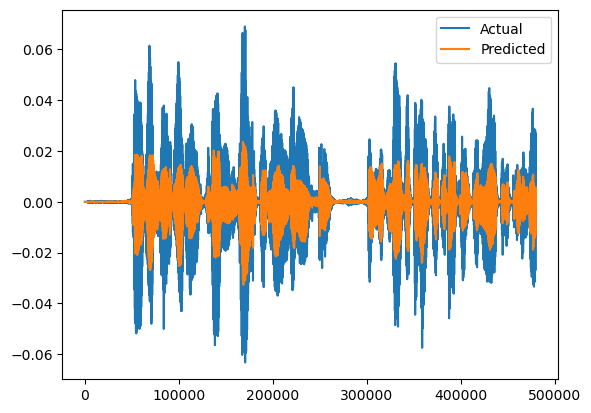

In [48]:
plt.plot(actual_panel_effect[:length], label="Actual")
plt.plot(predicted_panel_effect[:length], label="Predicted")
plt.legend()
plt.show()

In [49]:
from scipy.signal import correlate, correlation_lags

corr = correlate(ref_on, ref_off, mode="full", method="fft")
lags = correlation_lags(len(ref_on), len(ref_off), mode="full")

lag = lags[np.argmax(np.abs(corr))]

print("lag:", lag)
print("lag ms:", lag / 96000 * 1000)

lag: 806
lag ms: 8.395833333333334


In [50]:
if lag > 0:
    ref_on_a   = ref_on[lag:]
    error_on_a = error_on[lag:]

    ref_off_a   = ref_off[:-lag]
    error_off_a = error_off[:-lag]

elif lag < 0:
    k = -lag

    ref_on_a   = ref_on[:-k]
    error_on_a = error_on[:-k]

    ref_off_a   = ref_off[k:]
    error_off_a = error_off[k:]

else:
    ref_on_a = ref_on
    ref_off_a = ref_off
    error_on_a = error_on
    error_off_a = error_off

In [51]:
actual_panel_effect = error_on_a - error_off_a

In [52]:
control_pred = -cancel_gain * fftconvolve(
    ref_on_a,
    w_opt,
    mode="full"
)[:len(ref_on_a)]

predicted_panel_effect = fftconvolve(
    control_pred,
    error_ir,
    mode="full"
)[:len(control_pred)]

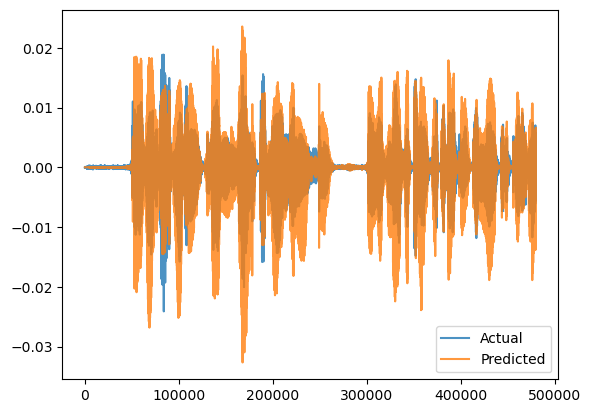

In [53]:
plt.plot(actual_panel_effect[:length], label="Actual", alpha=0.8)
plt.plot(predicted_panel_effect[:length], label="Predicted", alpha=0.8)
plt.legend()
plt.show()

In [54]:
print("RMS actual:   ", np.sqrt(np.mean(actual_panel_effect**2)))
print("RMS predicted:", np.sqrt(np.mean(predicted_panel_effect**2)))

RMS actual:    0.0024598755
RMS predicted: 0.004209255294942406


In [55]:
actual = actual_panel_effect
pred = predicted_panel_effect

In [56]:
from scipy.signal import correlate, correlation_lags

corr = correlate(actual, pred, mode="full", method="fft")
lags = correlation_lags(len(actual), len(pred), mode="full")

lag = lags[np.argmax(np.abs(corr))]

print("Best lag:", lag)
print("Best lag ms:", lag / 96_000 * 1000)

Best lag: 90
Best lag ms: 0.9375


In [57]:
if lag > 0:
    actual_a = actual[lag:]
    pred_a = pred[:-lag]

elif lag < 0:
    k = -lag
    actual_a = actual[:-k]
    pred_a = pred[k:]

else:
    actual_a = actual
    pred_a = pred

In [58]:
scale = np.dot(actual_a, pred_a) / (
    np.dot(pred_a, pred_a) + 1e-20
)

pred_fit = scale * pred_a

print("Best scale:", scale)

Best scale: 0.46631002114505743


In [59]:
residual = actual_a - pred_fit

nmse_db = 10 * np.log10(
    np.mean(residual**2) /
    np.mean(actual_a**2)
)

corrcoef = np.corrcoef(actual_a, pred_fit)[0, 1]

print("Model residual:", nmse_db, "dB")
print("Correlation:", corrcoef)

Model residual: -4.39704794119131 dB
Correlation: 0.7979192035991068


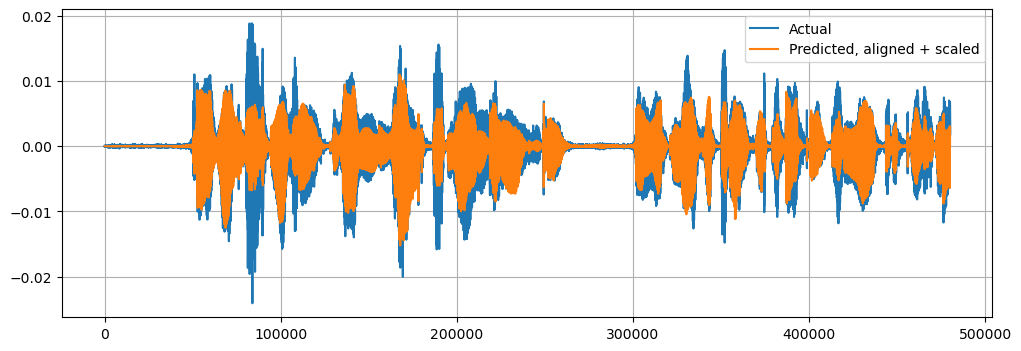

In [60]:


plt.figure(figsize=(12, 4))
plt.plot(actual_a[:length], label="Actual")
plt.plot(pred_fit[:length], label="Predicted, aligned + scaled")
plt.legend()
plt.grid()
plt.show()

Delay: 86 samples
Train: -18.84 dB
Test:  -17.06 dB
Norm:  1.581


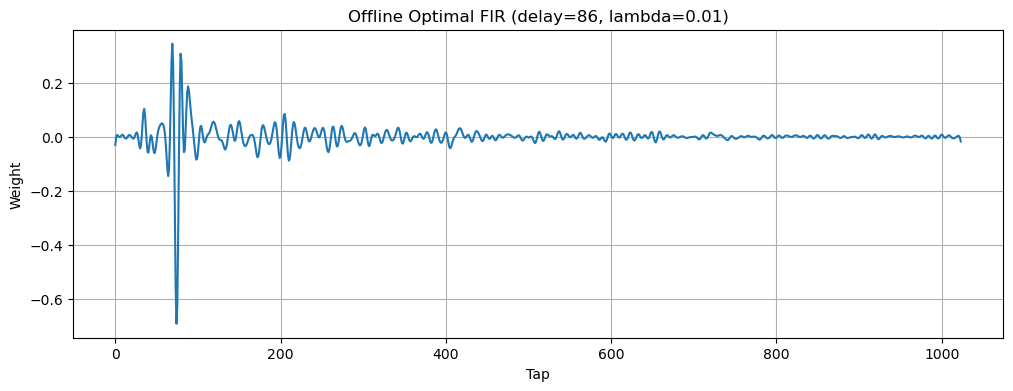

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# -------------------------------------------------------
# Settings
# -------------------------------------------------------

M = 1024
delay = 86
lam = 1e-2

# Use one 5-second recording
length = 5 * 96_000

error = error_nc[:length].astype(np.float64)
ref   = ref_nc[:length].astype(np.float64)


# -------------------------------------------------------
# 1. Pass reference through measured panel -> error IR
# -------------------------------------------------------

xf0 = fftconvolve(
    ref,
    error_ir,
    mode="full"
)[:len(ref)]


# -------------------------------------------------------
# 2. Add the SHARC input -> output latency
# -------------------------------------------------------

xf = np.zeros_like(xf0)

xf[delay:] = xf0[:-delay]


# -------------------------------------------------------
# 3. Build FIR regression matrix
#
# Each row is:
#
# [xf[n], xf[n-1], ..., xf[n-M+1]]
#
# Therefore X @ w predicts the panel contribution
# at the error mic.
# -------------------------------------------------------

N = len(xf)

X = np.zeros(
    (N - M + 1, M),
    dtype=np.float64,
)

for k in range(M):
    X[:, k] = xf[M - 1 - k : N - k]

# Error signal corresponding to those rows
d = error[M - 1:]


# -------------------------------------------------------
# 4. Train/test split
# -------------------------------------------------------

split = len(d) // 2

X_train = X[:split]
d_train = d[:split]

X_test = X[split:]
d_test = d[split:]


# -------------------------------------------------------
# 5. Ridge-regularized least squares
#
# minimize:
#
#     ||d + Xw||² + lambda ||w||²
#
# equivalent to:
#
#     Xw ≈ -d
# -------------------------------------------------------

X_aug = np.vstack([
    X_train,
    np.sqrt(lam) * np.eye(M),
])

d_aug = np.concatenate([
    -d_train,
    np.zeros(M),
])

w_delay86, *_ = np.linalg.lstsq(
    X_aug,
    d_aug,
    rcond=None,
)


# -------------------------------------------------------
# 6. Evaluate
# -------------------------------------------------------

train_residual = d_train + X_train @ w_delay86
test_residual  = d_test  + X_test @ w_delay86

train_db = 10 * np.log10(
    np.mean(train_residual**2) /
    np.mean(d_train**2)
)

test_db = 10 * np.log10(
    np.mean(test_residual**2) /
    np.mean(d_test**2)
)

print(f"Delay: {delay} samples")
print(f"Train: {train_db:.2f} dB")
print(f"Test:  {test_db:.2f} dB")
print(f"Norm:  {np.linalg.norm(w_delay86):.3f}")


# -------------------------------------------------------
# 7. Plot filter
# -------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(w_delay86)

plt.xlabel("Tap")
plt.ylabel("Weight")
plt.title(
    f"Offline Optimal FIR "
    f"(delay={delay}, lambda={lam:g})"
)

plt.grid()
plt.show()

In [ ]:
# start = 0
# length = int(5 * 96_000)

error = error_nc.astype(np.float64)
ref = ref_nc.astype(np.float64)

# FxLMS filtered reference
xf = fftconvolve(ref, error_ir.astype(np.float64), mode="full")[:len(ref)]

# Build delayed-reference matrix:
# row n contains [xf[n], xf[n-1], ..., xf[n-M+1]]
N = len(xf)
X = np.zeros((N - M + 1, M), dtype=np.float64)

for k in range(M):
    X[:, k] = xf[M - 1 - k : N - k]

d = error[M - 1:]

# Solve X w ≈ -d
w_opt, *_ = np.linalg.lstsq(X, -d, rcond=None)

predicted_control_at_error = X @ w_opt
residual = d + predicted_control_at_error

db = 10 * np.log10(
    np.mean(residual**2) / np.mean(d**2)
)

print("Offline optimal cancellation:", db, "dB")
print("Weight norm:", np.linalg.norm(w_opt))

Offline optimal cancellation: -18.03066769664713 dB
Weight norm: 16297.014322253353


In [16]:
def lsquare(X_train, d_train, X_test, d_test, lam):
    if lam == 0:
        w, *_ = np.linalg.lstsq(
            X_train,
            -d_train,
            rcond=None,
        )
    else:
        X_aug = np.vstack([
            X_train,
            np.sqrt(lam) * np.eye(M),
        ])

        d_aug = np.concatenate([
            -d_train,
            np.zeros(M),
        ])

        w, *_ = np.linalg.lstsq(
            X_aug,
            d_aug,
            rcond=None,
        )

    train_residual = d_train + X_train @ w
    test_residual = d_test + X_test @ w

    train_db = 10 * np.log10(
        np.mean(train_residual**2) /
        np.mean(d_train**2)
    )

    test_db = 10 * np.log10(
        np.mean(test_residual**2) /
        np.mean(d_test**2)
    )

    print("Train:", train_db)
    print("Test:", test_db)
    print("Norm:", np.linalg.norm(w))

    return w, train_db, test_db

In [17]:
split = len(d) // 2

X_train = X[:split]
d_train = d[:split]

X_test = X[split:]
d_test = d[split:]

In [18]:
lambdas = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
]

In [19]:
for lam in lambdas:
    print("lambda:", lam)

    w, train_db, test_db = lsquare(
        X_train,
        d_train,
        X_test,
        d_test,
        lam,
    )

    print()

lambda: 0
Train: -18.080435653867127
Test: -17.94574287582722
Norm: 15432.063915177074

lambda: 1e-08
Train: -18.074172918787415
Test: -17.937299130302936
Norm: 137.90150544847586

lambda: 1e-07
Train: -18.07202750537778
Test: -17.934508817369704
Norm: 48.28756201563156

lambda: 1e-06
Train: -18.0695314231767
Test: -17.931284572161374
Norm: 18.069703610670786

lambda: 1e-05
Train: -18.066231367045777
Test: -17.92731592914769
Norm: 9.171733883315467

lambda: 0.0001
Train: -18.05800627225423
Test: -17.91899462509694
Norm: 5.446014754384754

lambda: 0.001
Train: -18.03190173465419
Test: -17.894524439229254
Norm: 3.5899655620655913

lambda: 0.01
Train: -17.910786641398232
Test: -17.782268058269196
Norm: 2.293394836012435

lambda: 0.1
Train: -17.457661891679358
Test: -17.344236180813354
Norm: 1.4711539181453672

lambda: 1
Train: -15.888758543910438
Test: -15.757339477508655
Norm: 0.8914285673502493



Train: -17.910786641398232
Test: -17.782268058269196
Norm: 2.293394836012435


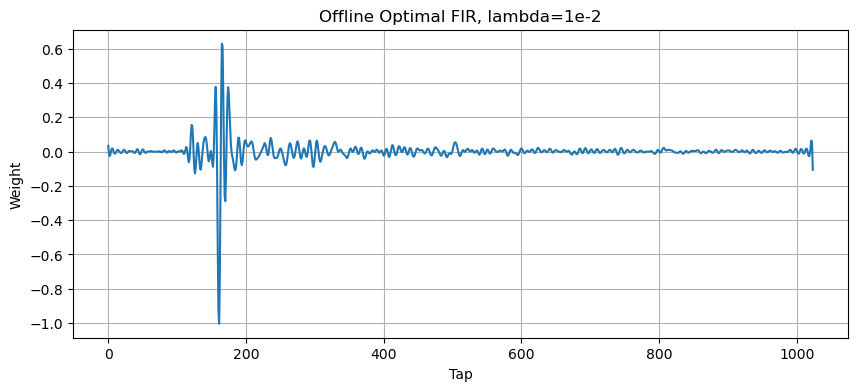

In [ ]:
w_1e2, train_db, test_db = lsquare(
    X_train,
    d_train,
    X_test,
    d_test,
    1e-2,
)

np.save(r".\data\w_opt_lam_1e-2.npy", w_1e2)

plt.figure(figsize=(10, 4))
plt.plot(w_1e2)
plt.xlabel("Tap")
plt.ylabel("Weight")
plt.title("Offline Optimal FIR, lambda=1e-2")
plt.grid(True)
plt.show()

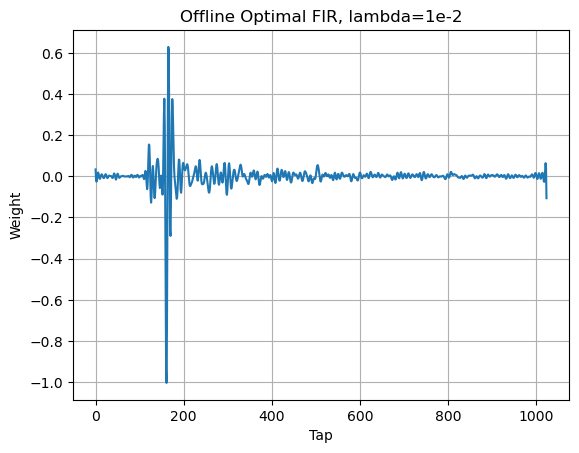

In [22]:
plt.plot(w_1e2)
plt.xlabel("Tap")
plt.ylabel("Weight")
plt.title("Offline Optimal FIR, lambda=1e-2")
plt.grid()


In [24]:
from pathlib import Path

path = Path(r'..\sharc\reverb\reverb_core1\src\filter_seed.h')

path.parent.mkdir(parents=True, exist_ok=True)

with path.open("w") as f:
    f.write("#pragma once\n\n")

    f.write(f"#define SEED_LEN {len(w_1e2)}\n\n")

    f.write("static const float seed[SEED_LEN] = {\n")
    for v in w_1e2:
        f.write(f"    {float(v):.9e}f,\n")
    f.write("};\n\n")

In [ ]:
# start = 0
# length = int(5 * 96_000)

error = error_nc.astype(np.float64)
ref = ref_nc.astype(np.float64)

# FxLMS filtered reference
xf = fftconvolve(ref, error_ir.astype(np.float64), mode="full")[:len(ref)]

# Build delayed-reference matrix:
# row n contains [xf[n], xf[n-1], ..., xf[n-M+1]]
N = len(xf)
X = np.zeros((N - M + 1, M), dtype=np.float64)

for k in range(M):
    X[:, k] = xf[M - 1 - k : N - k]

d = error[M - 1:]

# Solve X w ≈ -d
w_opt, *_ = np.linalg.lstsq(X, -d, rcond=None)

predicted_control_at_error = X @ w_opt
residual = d + predicted_control_at_error

db = 10 * np.log10(
    np.mean(residual**2) / np.mean(d**2)
)

print("Offline optimal cancellation:", db, "dB")
print("Weight norm:", np.linalg.norm(w_opt))

Offline optimal cancellation: -18.03066769664713 dB
Weight norm: 16297.014322253353
